# TD3 & baselines on `Walker2d-v5`

## Setup

In [ ]:
# %pip install stable-baselines3 imageio-ffmpeg
import os
import pandas as pd
from IPython.display import Image, display
import td3_algorithm as algo   # the TD3 algorithm (Actor/Critic/TD3Agent/ReplayBuffer)
import config       # ExperimentConfig + results-IO helpers
import training     # our TD3 training driver
import baselines    # Stable-Baselines3 baselines
import plotting     # comparison plots + summary table
import video        # progress-video rendering
print('device:', algo.device)

## Config

In [ ]:
cfg = config.ExperimentConfig(
    env_id="Walker2d-v5",
    max_timesteps=1000000,
    start_timesteps=25000,
    eval_freq=5_000,
    results_dir="results",   # -> results/Walker2d-v5/{logs,models,videos}
)
TD3_SEEDS = [0, 1]
SB3_SEEDS = [0, 1]
cfg

## Our TD3

In [ ]:
df_ours = training.run_multi_seed(cfg, TD3_SEEDS)
df_ours.tail()

## Stable-Baselines3 baselines: TD3, DDPG, SAC, PPO

In [ ]:
df_sb3 = baselines.run_all_baselines(cfg, SB3_SEEDS,
                                    algos=['TD3', 'DDPG', 'SAC', 'PPO'],
                                    snapshot_algos=['DDPG'])
df_sb3.tail()

## Compare all algorithms

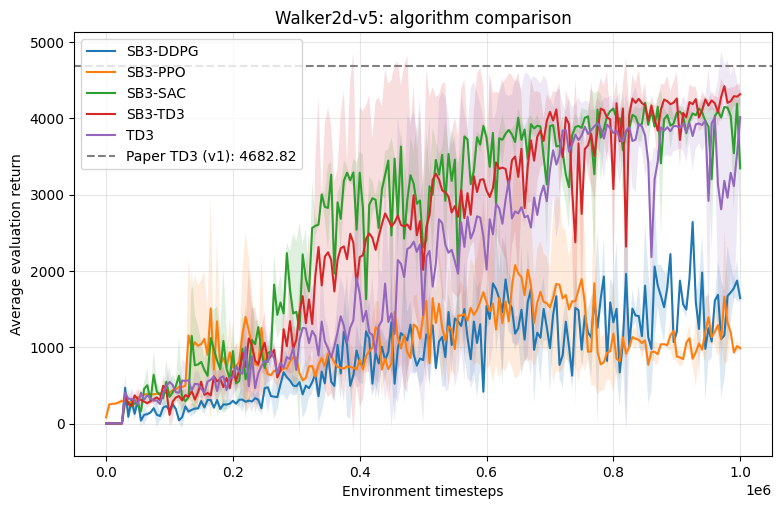

In [6]:
df_all = pd.concat([df_ours, df_sb3], ignore_index=True)
plotting.plot_compare(df_all, cfg.env_id)
plotting.summarize(df_all)

## TD3 training-progress video

In [ ]:
# Render the TD3 progress video from existing snapshots -- never retrains.
# Skips re-rendering if the GIF already exists, so Run All stays fast.
vid_seed = TD3_SEEDS[0]
gif = os.path.join(cfg.results_dir, cfg.env_id, 'videos', f'progress_TD3_{cfg.env_id}_seed{vid_seed}.gif')
if not os.path.exists(gif):
    gif = video.make_progress_video(cfg, seed=vid_seed)
if gif and os.path.exists(gif):
    display(Image(filename=gif))

## DDPG training-progress video

In [ ]:
# Render DDPG's progress video from its snapshots; skip if the GIF already exists.
gif_ddpg = os.path.join(cfg.results_dir, cfg.env_id, 'videos',
                        f'progress_SB3-DDPG_{cfg.env_id}_seed{SB3_SEEDS[0]}.gif')
if not os.path.exists(gif_ddpg):
    gif_ddpg = video.make_sb3_progress_video(cfg, seed=SB3_SEEDS[0], algo='DDPG')
if gif_ddpg and os.path.exists(gif_ddpg):
    display(Image(filename=gif_ddpg))